In [2]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import sys
import numpy as np
from thesis_ml.ising_vae import VAE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import sklearn.cluster as skl_cluster
from sklearn import manifold, decomposition, datasets
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.cluster import SpectralClustering
import statistics
import matplotlib.patches as mpatches
import glob
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm 

2025-08-04 12:26:14.607734: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-04 12:26:14.634111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754324774.650050   29374 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754324774.654925   29374 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754324774.667159   29374 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [6]:
#  Configuration 
data_dir = "training128"
MAX_FILES = 2
BATCH_SIZE = 100  # number of files per batch
OUTPUT_FILE = "good16.2_batched.npy"
DTYPE = np.int8  # Change this if your spin values are not small integers

#  Get and filter filenames 
file_list = sorted([
    f for f in os.listdir(data_dir)
    if os.path.isfile(os.path.join(data_dir, f))
])[:MAX_FILES]

#  Determine shape by peeking into the first valid line 
for fname in file_list:
    with open(os.path.join(data_dir, fname), 'r') as f:
        for line in f:
            if line.strip():
                sample_shape = len(line.strip().split())
                break
    if sample_shape:
        break

print("Scanning file line counts...")
total_lines = 0
line_counts = []
for fname in file_list:
    count = sum(1 for _ in open(os.path.join(data_dir, fname)))
    line_counts.append(count)
    total_lines += count

print(f"Estimated total lines: {total_lines}")

#  Preallocate output array using memmap 
out_array = np.lib.format.open_memmap(
    OUTPUT_FILE,
    mode='w+',
    dtype=DTYPE,
    shape=(total_lines, sample_shape)
)

#  Process files in batches 
cursor = 0
for i in range(0, len(file_list), BATCH_SIZE):
    batch_files = file_list[i:i + BATCH_SIZE]
    batch_data = []

    for fname in batch_files:
        with open(os.path.join(data_dir, fname), 'r') as f:
            for line in f:
                try:
                    values = [int(x) for x in line.strip().split()]
                    if len(values) == sample_shape:
                        batch_data.append(values)
                except ValueError:
                    print(f"Skipping bad line in {fname}: {line!r}")

    batch_data = np.array(batch_data, dtype=DTYPE)
    out_array[cursor:cursor + len(batch_data)] = batch_data
    cursor += len(batch_data)

    print(f"Processed {i + len(batch_files)} / {len(file_list)} files...")

print(f"\nFinal saved shape: {out_array.shape}")
print(f"Saved to: {OUTPUT_FILE}")


Scanning file line counts...
Estimated total lines: 108
Processed 2 / 2 files...

Final saved shape: (108, 16384)
Saved to: good16.2_batched.npy


In [7]:
data = np.load("good16.2_batched.npy")

In [8]:
#VAE expect images so we need to unflatten the data
flat_data = data
side_length = int(data.shape[1]**0.5)
data = data.reshape(-1, side_length, side_length)  # Shape: (4000, 32, 32)
# np.savetxt("ising_dataset.txt", data.reshape(data.shape[0], -1), delimiter=',')
print(data.shape)

(108, 128, 128)


Shape of data: (108, 128, 128)


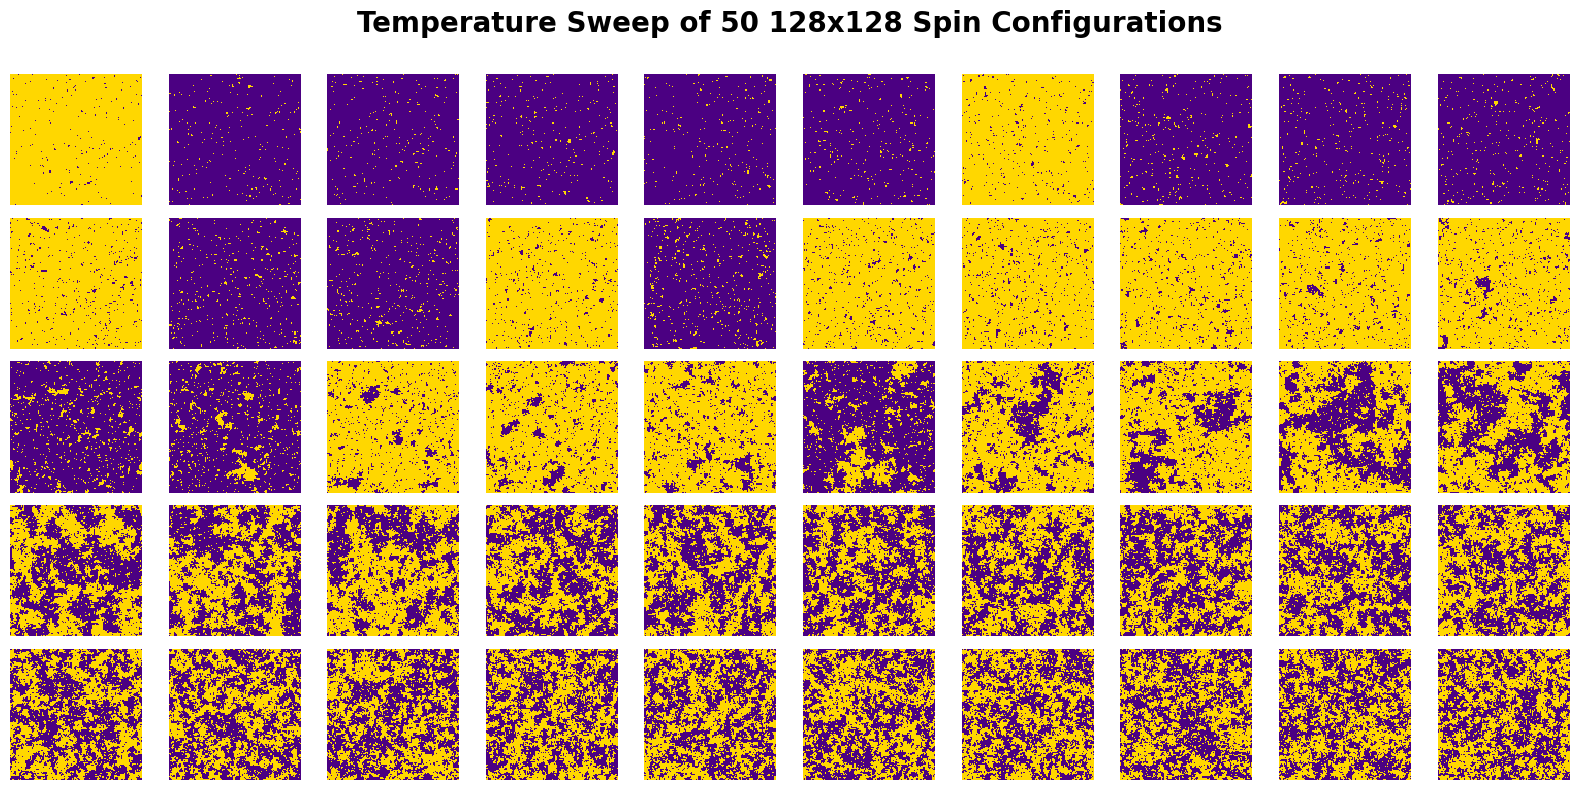

In [9]:
from matplotlib.colors import LinearSegmentedColormap

purple_orange_cmap = LinearSegmentedColormap.from_list("purple_orange", ["indigo", "gold"])


def visualize_ising_grid(spins_batch, title="First 50 Spin Configurations", save_path=None):

    
    if not isinstance(spins_batch, np.ndarray):
        raise TypeError("spins_batch must be a NumPy array")
    if spins_batch.ndim != 3:
        raise ValueError("spins_batch must be a 3D array of shape (N, H, W)")
    if spins_batch.shape[0] < 50:
        raise ValueError("Need at least 50 spin configurations for a 5x10 grid.")

    rows, cols = 5, 10
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8), facecolor='white')
    fig.suptitle(title, fontsize=20, weight='bold', color='black')

    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            spin_map = (spins_batch[idx] + 1) / 2  # Convert -1 → 0, +1 → 1
            ax = axes[i, j]
            ax.imshow(spin_map, cmap=purple_orange_cmap, interpolation='nearest')
            ax.axis('off')
            ax.set_xticks([])
            ax.set_yticks([])
            # Optional: light gray border
            for spine in ax.spines.values():
                spine.set_edgecolor('lightgray')
                spine.set_linewidth(0.5)

    plt.tight_layout(pad=1.0)
    plt.subplots_adjust(top=0.90)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()



# Example usage
if __name__ == "__main__":
    print("Shape of data:", data.shape)
    visualize_ising_grid(data, title="Temperature Sweep of 50 128x128 Spin Configurations")


In [ ]:
from scipy.signal import savgol_filter

# Critical temperature
Tc = 2.269185314

# Savitzky-Golay config
window_length = 7
polyorder = 5

# Files: name → data
files = {
    16:  "conductance_binned_final16.1.csv",
    # 32:  "conductance_binned_good32.1.csv",
    # 64:  "conductance_binned_good64.1.csv",
    # 128: "conductance_binned_good128.1.csv",
    # 256:  "conductance_binned_good256.1.csv",

}

for L, filename in files.items():
    print(f"\nProcessing L = {L}")
    data = np.loadtxt(filename, delimiter=",", skiprows=1)
    temp = data[:, 0]
    magnetized_avg = 1.0 - data[:, 3]  # 1 - disordered_avg
    magnetized_se = data[:, 4]
    disordered_avg = data[:, 3]
    disordered_se = data[:, 4]

    # Smooth magnetized curve
    smoothed_mag = savgol_filter(magnetized_avg, window_length=window_length, polyorder=polyorder)

    # Derivatives
    delta_T = np.mean(np.diff(temp))
    dmag_dT_smooth = savgol_filter(magnetized_avg, window_length=window_length, polyorder=polyorder, deriv=1, delta=delta_T)
    dmag_dT_numerical = np.gradient(magnetized_avg, temp)

    # Interpolate smoothed conductance at Tc
    mag_at_Tc = np.interp(Tc, temp, smoothed_mag)
    print(f"Interpolated conductance at Tc for L = {L}: {mag_at_Tc:.6f}")
    mag_Tc_column = np.full_like(temp, mag_at_Tc)  # constant column

    # Save output
    output_array = np.column_stack([
        temp,
        smoothed_mag,
        magnetized_se,
        disordered_avg,
        disordered_se,
        dmag_dT_smooth,
        mag_Tc_column
    ])
    output_filename = f"conductance_deriv_good{L}.3.csv"
    header = "temp_scaled,magnetized_avg,magnetized_se,disordered_avg,disordered_se,smoothed_derivative,interpolated_conductance_at_Tc"
    np.savetxt(output_filename, output_array, delimiter=",", header=header, comments='')
    print(f"Saved {output_filename}")

    # Plot comparison of derivatives
    plt.figure(figsize=(5, 4))
    plt.plot(temp, dmag_dT_numerical, label="Numerical Derivative", color="gray", linestyle='--')
    plt.plot(temp, dmag_dT_smooth, label="Smoothed Derivative", color="blue")
    # plt.axvline(Tc, color='orange', linestyle='--', label="Tc")
    plt.title(f"Derivative Comparison (L = {L})")
    plt.xlabel("Temperature")
    plt.ylabel("dM/dT")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


L=16: Peak cond temp = 1.0543478260869565, Peak mag temp = 1.0356139648451823
L=32: Peak cond temp = 1.0286951821864294, Peak mag temp = 1.01732546291281
L=64: Peak cond temp = 1.014586907378513, Peak mag temp = 1.008920935577675
L=128: Peak cond temp = 1.006881185905648, Peak mag temp = 1.0043692711824064
L=256: Peak cond temp = 1.0030702124489423, Peak mag temp = 1.0022845507451579


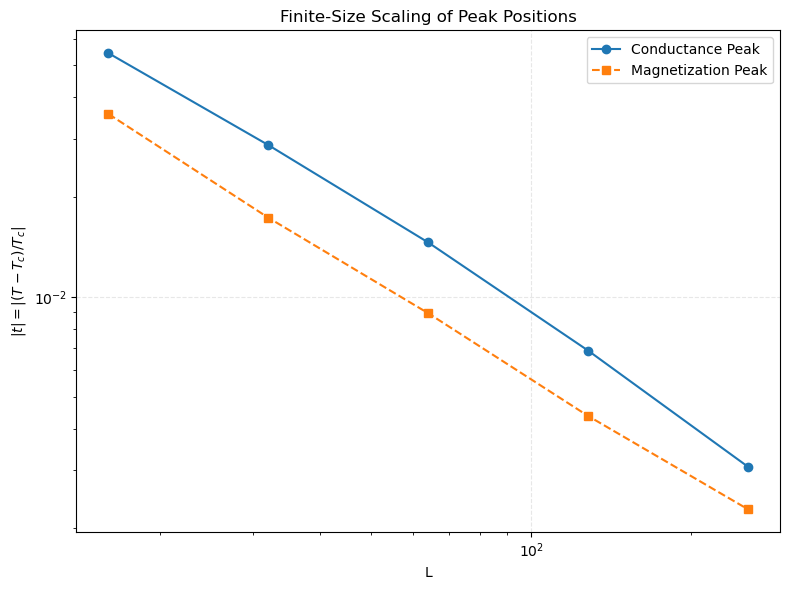

Conductance peak exponent estimate: slope = -1.0352 → nu ≈ 0.9660
Magnetization peak exponent estimate: slope = -0.9912 → nu ≈ 1.0088


In [10]:
from scipy.stats import linregress

Tc = 2.269185314
derivative_files = {
    256: "conductance_deriv_good256.2.csv",
    128: "conductance_deriv_good128.2.csv",
    64:  "conductance_deriv_good64.2.csv",
    32:  "conductance_deriv_good32.2.csv",
    16:  "conductance_deriv_good16.2.csv",
}
magnetization_files = {
    256: "mag_deriv_good256.1.csv",
    128: "mag_deriv_good128.1.csv",
    64:  "mag_deriv_good64.1.csv",
    32:  "mag_deriv_good32.1.csv",
    16:  "mag_deriv_good16.1.csv",
}

L_vals = []
reduced_temps_cond = []
reduced_temps_mag = []

for L in sorted(derivative_files.keys()):
    data_cond = np.loadtxt(derivative_files[L], delimiter=',', skiprows=1)
    temps_cond = data_cond[:, 0]
    deriv_cond = data_cond[:, 5]
    peak_temp_cond = temps_cond[np.argmax(deriv_cond)]
    t_cond = (peak_temp_cond*Tc - Tc) / Tc
    reduced_temps_cond.append(t_cond)

    data_mag = np.loadtxt(magnetization_files[L], delimiter=',', skiprows=1)
    temps_mag = data_mag[:, 0]
    deriv_mag = -data_mag[:, 2]
    peak_temp_mag = temps_mag[np.argmax(deriv_mag)]  # use argmax here
    t_mag = (peak_temp_mag*Tc - Tc) / Tc
    reduced_temps_mag.append(t_mag)
    print(f"L={L}: Peak cond temp = {peak_temp_cond}, Peak mag temp = {peak_temp_mag}")
    L_vals.append(L)

L_vals = np.array(L_vals)
abs_t_cond = np.abs(reduced_temps_cond)
abs_t_mag = np.abs(reduced_temps_mag)

# Log-log plot
plt.figure(figsize=(8,6))
plt.loglog(L_vals, abs_t_cond, 'o-', label='Conductance Peak')
plt.loglog(L_vals, abs_t_mag, 's--', label='Magnetization Peak')
plt.xlabel("L")
plt.ylabel(r"$|t| = |(T - T_c)/T_c|$")
plt.title("Finite-Size Scaling of Peak Positions")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Linear fit in log-log space to estimate exponent
log_L = np.log(L_vals)
log_t_cond = np.log(abs_t_cond)
log_t_mag = np.log(abs_t_mag)

fit_cond = linregress(log_L, log_t_cond)
fit_mag = linregress(log_L, log_t_mag)

print(f"Conductance peak exponent estimate: slope = {fit_cond.slope:.4f} → nu ≈ {-1/fit_cond.slope:.4f}")
print(f"Magnetization peak exponent estimate: slope = {fit_mag.slope:.4f} → nu ≈ {-1/fit_mag.slope:.4f}")


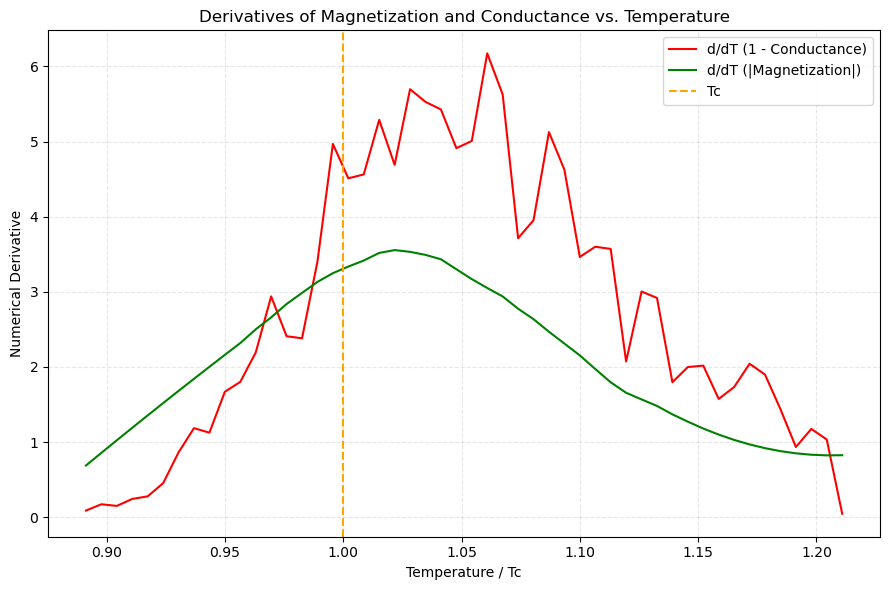

In [13]:
# Load CSVs
conductance_data = np.loadtxt("16_not_smooth_derivative.csv", delimiter=",", skiprows=1)
magnetization_data = np.loadtxt("magnetization_derivative_not_smooth16.csv", delimiter=",", skiprows=1)

# Unpack
temps_conductance, dC_dT = conductance_data[:, 0], conductance_data[:, 1]
temps_magnetization, dM_dT = magnetization_data[:, 0], magnetization_data[:, 1]

# Plot
plt.figure(figsize=(9, 6))
plt.plot(temps_conductance, dC_dT, label='d/dT (1 - Conductance)', color='red')
plt.plot(temps_magnetization, dM_dT, label='d/dT (|Magnetization|)', color='green')

# Add Tc line
plt.axvline(1.0, color='orange', linestyle='--', label='Tc')

# Labels and formatting
plt.xlabel("Temperature / Tc")
plt.ylabel("Numerical Derivative")
plt.title("Derivatives of Magnetization and Conductance vs. Temperature")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


L = 16 → Conductance at Tc: 0.836558
L = 32 → Conductance at Tc: 0.858316
L = 64 → Conductance at Tc: 0.859503
L = 128 → Conductance at Tc: 0.859321
L = 256 → Conductance at Tc: 0.813045

Saved conductance heights at Tc to 'interpolated_conductance_at_Tc.csv'
Intersection between L=16 and L=32 at T/Tc ≈ 1.0049
Intersection between L=32 and L=64 at T/Tc ≈ 1.0002
Intersection between L=64 and L=128 at T/Tc ≈ 1.0000
Intersection between L=128 and L=256 at T/Tc ≈ 0.9986

Saved conductance curve intersections to 'intersections_conductance_curves.csv'


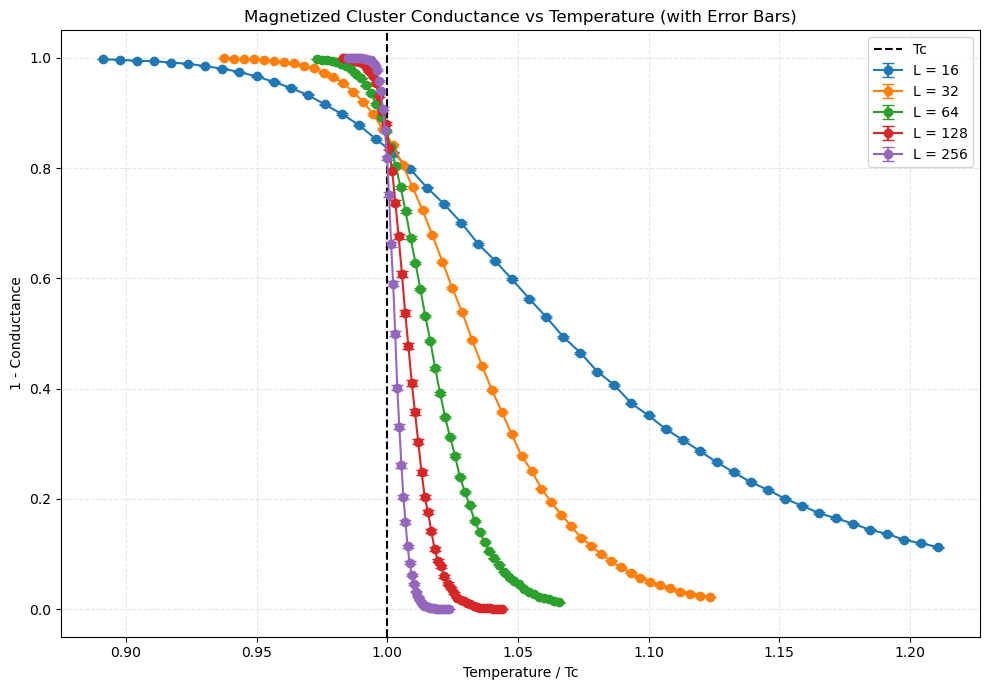

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import csv

# Tc
Tc_scaled = 1.0

#  Load data 
datasets = {
    16: np.loadtxt("conductance_binned_final16.1.csv", delimiter=",", skiprows=1),
    32: np.loadtxt("conductance_binned_good32.1.csv", delimiter=",", skiprows=1),
    64: np.loadtxt("conductance_binned_good64.1.csv", delimiter=",", skiprows=1),
    128: np.loadtxt("conductance_binned_good128.1.csv", delimiter=",", skiprows=1),
    256: np.loadtxt("conductance_binned_good256.1.csv", delimiter=",", skiprows=1),
}

# Store interpolated height at Tc
interpolated_heights = [("L", "conductance_at_Tc")]

# Store curves for later intersection analysis
conductance_curves = {}

#  Plot 
plt.figure(figsize=(10, 7))

for L, data in datasets.items():
    temp = data[:, 0]
    conductance = data[:, 3]
    error = data[:, 4]

    # Plot
    plt.errorbar(temp, conductance, yerr=error, fmt='o-', capsize=4, label=f"L = {L}")

    # Interpolation at Tc
    c_at_Tc = np.interp(Tc_scaled, temp, conductance)
    interpolated_heights.append((L, c_at_Tc))
    print(f"L = {L} → Conductance at Tc: {c_at_Tc:.6f}")

    # Store for intersection computation
    conductance_curves[L] = (temp, conductance)

#  Save heights at Tc 
with open("interpolated_conductance_at_Tc.csv", "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerows(interpolated_heights)

print("\nSaved conductance heights at Tc to 'interpolated_conductance_at_Tc.csv'")

#  Compute intersection points between adjacent curves 
def find_intersection(x1, y1, x2, y2):
    for i in range(len(x1) - 1):
        if (y1[i] - y2[i]) * (y1[i+1] - y2[i+1]) < 0:
            x_left, x_right = x1[i], x1[i+1]
            y_diff_left = y1[i] - y2[i]
            y_diff_right = y1[i+1] - y2[i+1]
            slope = (y_diff_right - y_diff_left) / (x_right - x_left)
            if slope == 0:
                return x_left
            x_cross = x_left - y_diff_left / slope
            return x_cross
    return None

intersection_results = [("L1", "L2", "intersection_temp_scaled")]

L_values = sorted(conductance_curves.keys())
for i in range(len(L_values) - 1):
    L1, L2 = L_values[i], L_values[i+1]
    x1, y1 = conductance_curves[L1]
    x2, y2 = conductance_curves[L2]

    # Interpolate both onto common grid
    common_x = np.linspace(max(min(x1), min(x2)), min(max(x1), max(x2)), 500)
    y1_interp = np.interp(common_x, x1, y1)
    y2_interp = np.interp(common_x, x2, y2)

    x_cross = find_intersection(common_x, y1_interp, common_x, y2_interp)
    if x_cross:
        print(f"Intersection between L={L1} and L={L2} at T/Tc ≈ {x_cross:.4f}")
        intersection_results.append((L1, L2, x_cross))
    else:
        print(f"No intersection between L={L1} and L={L2}")

#  Save intersections 
with open("intersections_conductance_curves.csv", "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerows(intersection_results)

print("\nSaved conductance curve intersections to 'intersections_conductance_curves.csv'")

#  Plot decorations 
plt.axvline(Tc_scaled, color='black', linestyle='--', linewidth=1.5, label='Tc')
plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title("Magnetized Cluster Conductance vs Temperature (with Error Bars)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



Processing L = 16
Interpolated |M| at Tc for L = 16: 0.713430

Processing L = 32
Interpolated |M| at Tc for L = 32: 0.653434

Processing L = 64
Interpolated |M| at Tc for L = 64: 0.600349

Processing L = 128
Interpolated |M| at Tc for L = 128: 0.552455

Processing L = 256
Interpolated |M| at Tc for L = 256: 0.506747


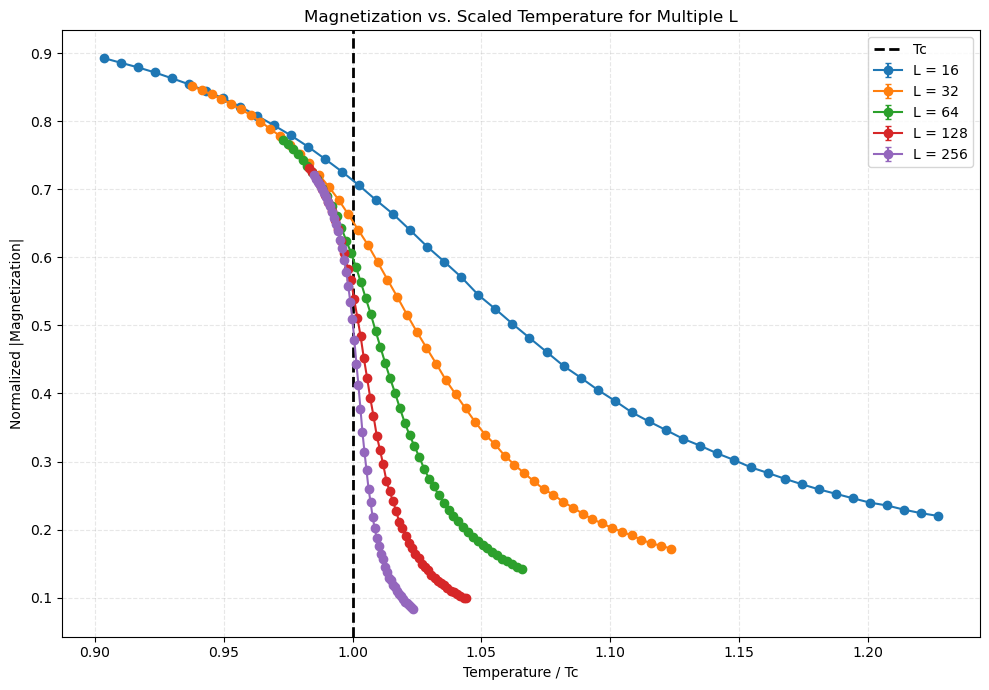


Saved interpolated values to 'interpolated_magnetization_at_Tc.csv'


In [18]:
#  Constants 
Tc = 2.269185314
sizes = [16, 32, 64, 128, 256]
bins_per_temp = 1  # number of bins per temperature

# Prepare plot
plt.figure(figsize=(10, 7))

# Prepare list to store interpolated values
interpolated_data = [("L", "magnetization_at_Tc")]

for L in sizes:
    print(f"\nProcessing L = {L}")
    mags = np.load(f"magnetizations_good{L}.1.npy")
    if L == 64:
        mags = mags[:10000000]  # To match other data if truncated

    temps = np.load(f"temperature_labels_good{L}.1.npy")
    if L == 64:
        temps = temps[:10000000]

    temps_scaled = temps / Tc
    magnetization_norm = np.abs(mags) / (L * L)

    # Bin magnetization by temperature
    unique_temps = np.unique(temps)
    bin_means, bin_stds, bin_counts, bin_centers = [], [], [], []

    for T in unique_temps:
        mask = temps == T
        indices = np.where(mask)[0]
        np.random.shuffle(indices)

        sub_bins = np.array_split(indices, bins_per_temp)
        for sub in sub_bins:
            # Filter out-of-bounds indices
            sub = sub[sub < len(magnetization_norm)]
            if len(sub) > 0:
                m_vals = magnetization_norm[sub]
                bin_means.append(np.mean(m_vals))
                bin_stds.append(np.std(m_vals))
                bin_counts.append(len(m_vals))
                bin_centers.append(T / Tc)

    # Convert to arrays and sort
    bin_centers = np.array(bin_centers)
    bin_means = np.array(bin_means)
    bin_stds = np.array(bin_stds)
    bin_counts = np.array(bin_counts)
    bin_stderr = bin_stds / np.sqrt(bin_counts)

    sort_idx = np.argsort(bin_centers)
    bin_centers = bin_centers[sort_idx]
    bin_means = bin_means[sort_idx]
    bin_stderr = bin_stderr[sort_idx]

    # Interpolate magnetization at Tc
    mag_at_Tc = np.interp(1.0, bin_centers, bin_means)
    interpolated_data.append((L, mag_at_Tc))
    print(f"Interpolated |M| at Tc for L = {L}: {mag_at_Tc:.6f}")

    # Plot
    plt.errorbar(bin_centers, bin_means, yerr=bin_stderr, fmt='-o', capsize=2, label=f"L = {L}")

# Add Tc reference line
plt.axvline(1.0, color='black', linestyle='--', linewidth=2, label='Tc')

# Final plot settings
plt.xlabel("Temperature / Tc")
plt.ylabel("Normalized |Magnetization|")
plt.title("Magnetization vs. Scaled Temperature for Multiple L")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#  Save interpolated values to CSV 
with open("interpolated_magnetization_at_Tc.csv", "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerows(interpolated_data)

print("\nSaved interpolated values to 'interpolated_magnetization_at_Tc.csv'")


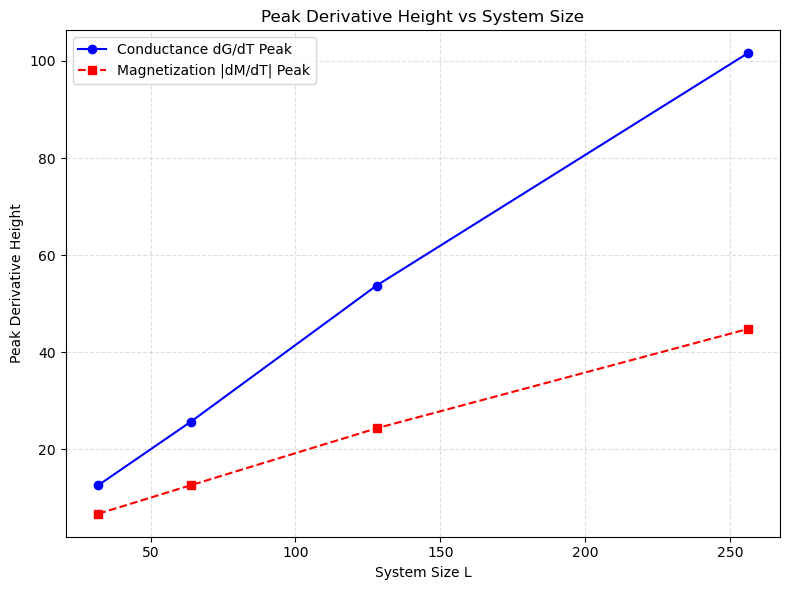

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Files
derivative_files = {
    256: "conductance_deriv_good256.3.csv",
    128: "conductance_deriv_good128.3.csv",
    64:  "conductance_deriv_good64.3.csv",
    32:  "conductance_deriv_good32.3.csv",
    # 16:  "conductance_deriv_good16.3.csv",
}

magnetization_files = {
    256: "mag_deriv_good256.1.csv",
    128: "mag_deriv_good128.1.csv",
    64:  "mag_deriv_good64.1.csv",
    32:  "mag_deriv_good32.1.csv",
    # 16:  "mag_deriv_good16.1.csv",
}

# Collect data
L_vals = []
peak_heights_cond = []
peak_heights_mag = []

for L in sorted(derivative_files):
    #  Conductance 
    data_cond = np.loadtxt(derivative_files[L], delimiter=',', skiprows=1)
    temp_cond = data_cond[:, 0]
    deriv_cond = data_cond[:, 5]  

    peak_val_cond = np.max(deriv_cond)  # assuming positive peak
    peak_heights_cond.append(peak_val_cond)

    #  Magnetization 
    data_mag = np.loadtxt(magnetization_files[L], delimiter=',', skiprows=1)
    temp_mag = data_mag[:, 0]
    deriv_mag = data_mag[:, 2]

    peak_val_mag = np.min(deriv_mag)  # negative peak for -dM/dT
    peak_heights_mag.append(-peak_val_mag)  # flip sign to plot positive peak height

    L_vals.append(L)

# Convert to arrays
L_vals = np.array(L_vals)
peak_heights_cond = np.array(peak_heights_cond)
peak_heights_mag = np.array(peak_heights_mag)

#  Plot 
plt.figure(figsize=(8, 6))
plt.plot(L_vals, peak_heights_cond, 'o-', color='blue', label='Conductance dG/dT Peak')
plt.plot(L_vals, peak_heights_mag, 's--', color='red', label='Magnetization |dM/dT| Peak')

plt.xlabel("System Size L")
plt.ylabel("Peak Derivative Height")
plt.title("Peak Derivative Height vs System Size")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


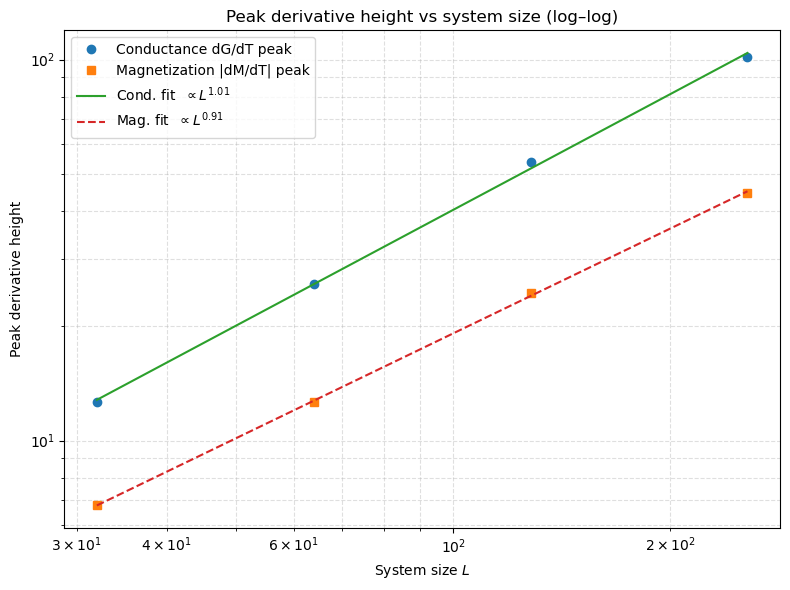

Conductance exponent k = 1.0082,  R² = 0.9991
Magnetization exponent k = 0.9131,  R² = 0.9998


In [20]:

#  Power‑law (log‑log) least‑squares fits 
log_L  = np.log10(L_vals)

# Conductance dG/dT peak
log_cond = np.log10(peak_heights_cond)
slope_c, intercept_c, r_c, _, _ = linregress(log_L, log_cond)
fit_cond = 10**intercept_c * L_vals**slope_c        # back‑transform

# Magnetization |dM/dT| peak
log_mag = np.log10(peak_heights_mag)
slope_m, intercept_m, r_m, _, _ = linregress(log_L, log_mag)
fit_mag = 10**intercept_m * L_vals**slope_m

#  Plot (log–log) 
plt.figure(figsize=(8, 6))

# data points
plt.loglog(L_vals, peak_heights_cond, 'o', label='Conductance dG/dT peak')
plt.loglog(L_vals, peak_heights_mag,  's', label='Magnetization |dM/dT| peak')

# best‑fit lines
plt.loglog(L_vals, fit_cond, '-',  lw=1.5,
           label=fr'Cond. fit  $\propto L^{{{slope_c:.2f}}}$')
plt.loglog(L_vals, fit_mag,  '--', lw=1.5,
           label=fr'Mag. fit  $\propto L^{{{slope_m:.2f}}}$')

plt.xlabel(r'System size $L$')
plt.ylabel('Peak derivative height')
plt.title('Peak derivative height vs system size (log–log)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: print numerical fit details
print(f"Conductance exponent k = {slope_c:.4f},  R² = {r_c**2:.4f}")
print(f"Magnetization exponent k = {slope_m:.4f},  R² = {r_m**2:.4f}")


L=16: Peak cond temp = 1.054348, Peak mag temp = 1.035614
L=32: Peak cond temp = 1.028695, Peak mag temp = 1.017325
L=64: Peak cond temp = 1.014587, Peak mag temp = 1.008921
L=128: Peak cond temp = 1.006881, Peak mag temp = 1.004369
L=256: Peak cond temp = 1.003070, Peak mag temp = 1.002285


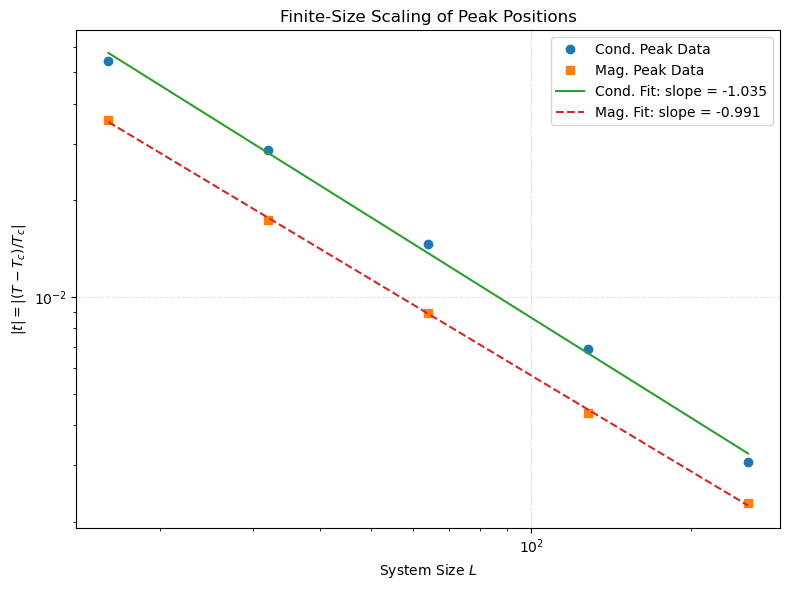

Conductance peak exponent estimate: slope = -1.0352 → ν ≈ 0.9660
Magnetization peak exponent estimate: slope = -0.9912 → ν ≈ 1.0088


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

Tc = 2.269185314

#  File paths 
derivative_files = {
    256: "conductance_deriv_good256.3.csv",
    128: "conductance_deriv_good128.2.csv",
    64:  "conductance_deriv_good64.2.csv",
    32:  "conductance_deriv_good32.2.csv",
    16:  "conductance_deriv_good16.2.csv",
}
magnetization_files = {
    256: "mag_deriv_good256.1.csv",
    128: "mag_deriv_good128.1.csv",
    64:  "mag_deriv_good64.1.csv",
    32:  "mag_deriv_good32.1.csv",
    16:  "mag_deriv_good16.1.csv",
}

#  Data collection 
L_vals = []
reduced_temps_cond = []
reduced_temps_mag = []

for L in sorted(derivative_files.keys()):
    data_cond = np.loadtxt(derivative_files[L], delimiter=',', skiprows=1)
    temps_cond = data_cond[:, 0]
    deriv_cond = data_cond[:, 5]
    peak_temp_cond = temps_cond[np.argmax(deriv_cond)]
    t_cond = (peak_temp_cond * Tc - Tc) / Tc
    reduced_temps_cond.append(t_cond)

    data_mag = np.loadtxt(magnetization_files[L], delimiter=',', skiprows=1)
    temps_mag = data_mag[:, 0]
    deriv_mag = -data_mag[:, 2]
    peak_temp_mag = temps_mag[np.argmax(deriv_mag)]
    t_mag = (peak_temp_mag * Tc - Tc) / Tc
    reduced_temps_mag.append(t_mag)

    print(f"L={L}: Peak cond temp = {peak_temp_cond:.6f}, Peak mag temp = {peak_temp_mag:.6f}")
    L_vals.append(L)

L_vals = np.array(L_vals)
abs_t_cond = np.abs(reduced_temps_cond)
abs_t_mag = np.abs(reduced_temps_mag)

#  Linear regression in log-log space 
log_L = np.log(L_vals)
log_t_cond = np.log(abs_t_cond)
log_t_mag = np.log(abs_t_mag)

fit_cond = linregress(log_L, log_t_cond)
fit_mag = linregress(log_L, log_t_mag)

slope_cond = fit_cond.slope
slope_mag = fit_mag.slope

#  Fit lines for plot 
L_fit = np.linspace(L_vals.min(), L_vals.max(), 200)
fit_line_cond = np.exp(fit_cond.intercept) * L_fit**slope_cond
fit_line_mag = np.exp(fit_mag.intercept) * L_fit**slope_mag

#  Plot 
plt.figure(figsize=(8, 6))
plt.loglog(L_vals, abs_t_cond, 'o', label='Cond. Peak Data')
plt.loglog(L_vals, abs_t_mag, 's', label='Mag. Peak Data')
plt.loglog(L_fit, fit_line_cond, '-', label=fr'Cond. Fit: slope = {slope_cond:.3f}')
plt.loglog(L_fit, fit_line_mag, '--', label=fr'Mag. Fit: slope = {slope_mag:.3f}')

plt.xlabel("System Size $L$")
plt.ylabel(r"$|t| = |(T - T_c)/T_c|$")
plt.title("Finite-Size Scaling of Peak Positions")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#  Output slope estimates 
nu_cond = -1 / slope_cond
nu_mag = -1 / slope_mag

print(f"Conductance peak exponent estimate: slope = {slope_cond:.4f} → ν ≈ {nu_cond:.4f}")
print(f"Magnetization peak exponent estimate: slope = {slope_mag:.4f} → ν ≈ {nu_mag:.4f}")


Slope (Conductance vs L): -0.0081
Slope (Magnetization vs L): -0.1229


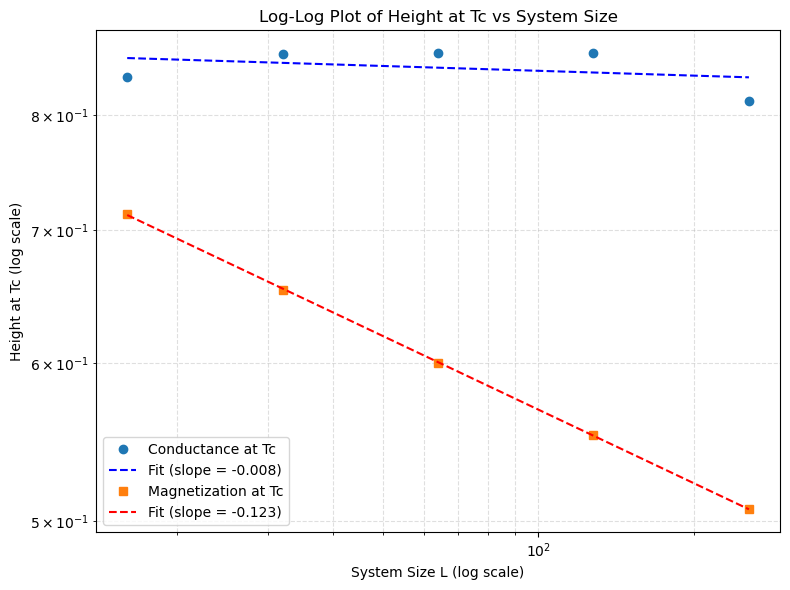

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import csv

#  Load Conductance Heights 
conductance_data = np.genfromtxt("interpolated_conductance_at_Tc.csv", delimiter=",", skip_header=1)
L_c, c_heights = conductance_data[:, 0], conductance_data[:, 1]

#  Load Magnetization Heights 
magnetization_data = np.genfromtxt("interpolated_magnetization_at_Tc.csv", delimiter=",", skip_header=1)
L_m, m_heights = magnetization_data[:, 0], magnetization_data[:, 1]

#  Take log10 for linear fit 
log_L_c = np.log10(L_c)
log_c = np.log10(c_heights)
log_L_m = np.log10(L_m)
log_m = np.log10(m_heights)

#  Fit linear lines in log-log space 
slope_c, intercept_c = np.polyfit(log_L_c, log_c, 1)
slope_m, intercept_m = np.polyfit(log_L_m, log_m, 1)

print(f"Slope (Conductance vs L): {slope_c:.4f}")
print(f"Slope (Magnetization vs L): {slope_m:.4f}")

#  Generate fit lines for plotting 
L_fit = np.linspace(min(min(L_c), min(L_m)), max(max(L_c), max(L_m)), 100)
c_fit = 10**(intercept_c + slope_c * np.log10(L_fit))
m_fit = 10**(intercept_m + slope_m * np.log10(L_fit))

#  Plot 
plt.figure(figsize=(8, 6))

plt.loglog(L_c, c_heights, 'o', label="Conductance at Tc", markersize=6)
plt.loglog(L_fit, c_fit, 'b--', label=f"Fit (slope = {slope_c:.3f})", linewidth=1.5)

plt.loglog(L_m, m_heights, 's', label="Magnetization at Tc", markersize=6)
plt.loglog(L_fit, m_fit, 'r--', label=f"Fit (slope = {slope_m:.3f})", linewidth=1.5)

plt.xlabel("System Size L (log scale)")
plt.ylabel("Height at Tc (log scale)")
plt.title("Log-Log Plot of Height at Tc vs System Size")
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("loglog_height_vs_L_with_slopes.png", dpi=300)
plt.show()


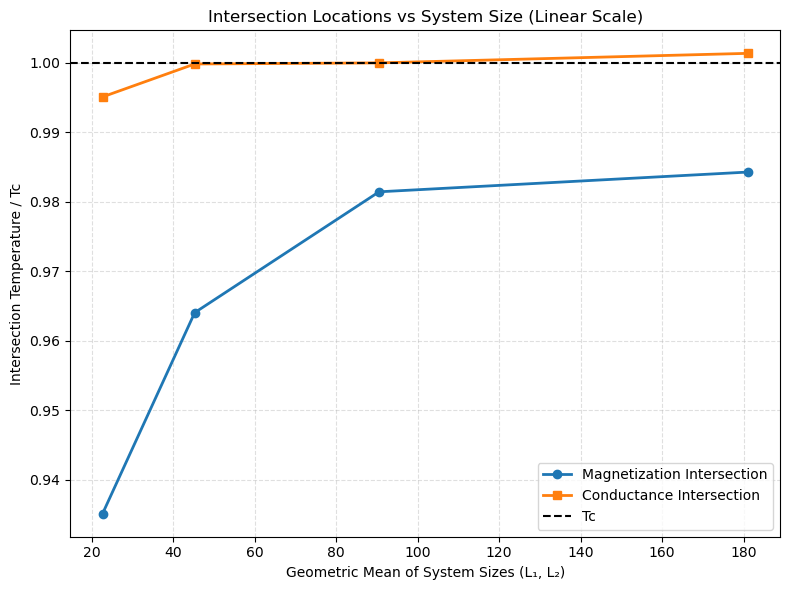

In [23]:
import numpy as np
import matplotlib.pyplot as plt

#  Load intersection CSVs 
mag_data = np.genfromtxt("intersections_between_sizes.csv", delimiter=",", skip_header=1)
cond_data = np.genfromtxt("intersections_conductance_curves.csv", delimiter=",", skip_header=1)

#  Extract and compute geometric mean of system sizes 
L_mag = np.sqrt(mag_data[:, 0] * mag_data[:, 1])
T_intersect_mag = mag_data[:, 2]

L_cond = np.sqrt(cond_data[:, 0] * cond_data[:, 1])
T_intersect_cond = cond_data[:, 2]

#  Plot 
plt.figure(figsize=(8, 6))

plt.plot(L_mag, T_intersect_mag, 'o-', label="Magnetization Intersection", linewidth=2, markersize=6)
plt.plot(L_cond, 2-T_intersect_cond, 's-', label="Conductance Intersection", linewidth=2, markersize=6)

plt.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Tc')

plt.xlabel("Geometric Mean of System Sizes (L₁, L₂)")
plt.ylabel("Intersection Temperature / Tc")
plt.title("Intersection Locations vs System Size (Linear Scale)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("intersection_locations_linear.png", dpi=300)
plt.show()
